In [1]:
"""
Complete Attention Mechanism Implementation
Build single-head, multi-head, and causal attention from scratch
Includes visualization utilities to understand how attention works
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


class SingleHeadAttention:
    """
    Single-head attention mechanism.
    
    Implements: Attention(Q, K, V) = softmax(QK^T / √d_k) V
    """
    
    def __init__(self, d_model, d_k):
        """
        Initialize attention layer.
        
        Args:
            d_model: Input embedding dimension
            d_k: Query/Key/Value dimension
        """
        self.d_model = d_model
        self.d_k = d_k
        
        # Weight matrices (learned during training)
        self.W_q = np.random.randn(d_model, d_k) * 0.1
        self.W_k = np.random.randn(d_model, d_k) * 0.1
        self.W_v = np.random.randn(d_model, d_k) * 0.1
    
    def forward(self, X, mask=None, return_attention=False):
        """
        Forward pass.
        
        Args:
            X: Input embeddings [seq_len, d_model]
            mask: Optional mask [seq_len, seq_len]
            return_attention: Return attention weights
            
        Returns:
            output: [seq_len, d_k]
            (optional) attention_weights: [seq_len, seq_len]
        """
        # Project to Q, K, V
        Q = X @ self.W_q  # [seq_len, d_k]
        K = X @ self.W_k  # [seq_len, d_k]
        V = X @ self.W_v  # [seq_len, d_k]
        
        # Compute attention scores
        scores = Q @ K.T / np.sqrt(self.d_k)  # [seq_len, seq_len]
        
        # Apply mask if provided
        if mask is not None:
            scores = scores + mask
        
        # Softmax to get attention weights
        attention_weights = self.softmax(scores)
        
        # Weighted sum of values
        output = attention_weights @ V
        
        if return_attention:
            return output, attention_weights
        return output
    
    @staticmethod
    def softmax(x):
        """Numerically stable softmax."""
        exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=-1, keepdims=True)


In [2]:

class MultiHeadAttention:
    """
    Multi-head attention: multiple attention heads in parallel.
    """
    
    def __init__(self, d_model, num_heads):
        """
        Args:
            d_model: Model dimension (must be divisible by num_heads)
            num_heads: Number of parallel attention heads
        """
        assert d_model % num_heads == 0
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        # Create attention heads
        self.heads = [
            SingleHeadAttention(d_model, self.d_k)
            for _ in range(num_heads)
        ]
        
        # Output projection
        self.W_o = np.random.randn(d_model, d_model) * 0.1
    
    def forward(self, X, mask=None, return_attention=False):
        """
        Forward pass through all heads.
        
        Args:
            X: Input [seq_len, d_model]
            
        Returns:
            output: [seq_len, d_model]
            (optional) List of attention weights from each head
        """
        head_outputs = []
        head_attentions = []
        
        # Run each head
        for head in self.heads:
            if return_attention:
                output, attn = head.forward(X, mask, return_attention=True)
                head_outputs.append(output)
                head_attentions.append(attn)
            else:
                output = head.forward(X, mask)
                head_outputs.append(output)
        
        # Concatenate heads
        concatenated = np.concatenate(head_outputs, axis=-1)
        
        # Final projection
        output = concatenated @ self.W_o
        
        if return_attention:
            return output, head_attentions
        return output



In [3]:

class TransformerLayer:
    """
    Complete transformer layer: attention + feed-forward + residuals.
    """
    
    def __init__(self, d_model, num_heads, d_ff=None):
        """
        Args:
            d_model: Model dimension
            num_heads: Number of attention heads
            d_ff: Feed-forward hidden dimension
        """
        self.d_model = d_model
        self.d_ff = d_ff or 4 * d_model
        
        # Multi-head attention
        self.attention = MultiHeadAttention(d_model, num_heads)
        
        # Feed-forward network
        self.W1 = np.random.randn(d_model, self.d_ff) * 0.1
        self.b1 = np.zeros(self.d_ff)
        self.W2 = np.random.randn(self.d_ff, d_model) * 0.1
        self.b2 = np.zeros(d_model)
    
    def forward(self, X, mask=None):
        """Forward pass through transformer layer."""
        # Multi-head attention + residual
        attn_output = self.attention.forward(X, mask)
        X = self.layer_norm(X + attn_output)
        
        # Feed-forward + residual
        ff_output = self.feed_forward(X)
        X = self.layer_norm(X + ff_output)
        
        return X
    
    def feed_forward(self, X):
        """Two-layer feed-forward with ReLU."""
        hidden = np.maximum(0, X @ self.W1 + self.b1)
        return hidden @ self.W2 + self.b2
    
    @staticmethod
    def layer_norm(X, eps=1e-6):
        """Layer normalization."""
        mean = X.mean(axis=-1, keepdims=True)
        std = X.std(axis=-1, keepdims=True)
        return (X - mean) / (std + eps)



ATTENTION MECHANISM: COMPLETE IMPLEMENTATION

DEMO 1: Single-Head Attention

Sentence: The cat sat on the mat
Input shape: (6, 8)
Output shape: (6, 4)

Attention patterns:
  'The' attends most to 'on' (weight: 0.167)
  'cat' attends most to 'on' (weight: 0.170)
  'sat' attends most to 'sat' (weight: 0.169)
  'on' attends most to 'sat' (weight: 0.172)
  'the' attends most to 'on' (weight: 0.167)
  'mat' attends most to 'mat' (weight: 0.167)
✓ Saved to single_head_attention.png


DEMO 2: Multi-Head Attention

Sentence: The cat sat on the mat
Number of heads: 4
Output shape: (6, 8)

Different attention patterns per head:

  Head 1:
    'The' → 'cat'
    'cat' → 'sat'
    'sat' → 'mat'
    'on' → 'on'
    'the' → 'cat'
    'mat' → 'mat'

  Head 2:
    'The' → 'mat'
    'cat' → 'mat'
    'sat' → 'mat'
    'on' → 'The'
    'the' → 'mat'
    'mat' → 'mat'

  Head 3:
    'The' → 'The'
    'cat' → 'The'
    'sat' → 'mat'
    'on' → 'on'
    'the' → 'The'
    'mat' → 'on'

  Head 4:
    'The' →

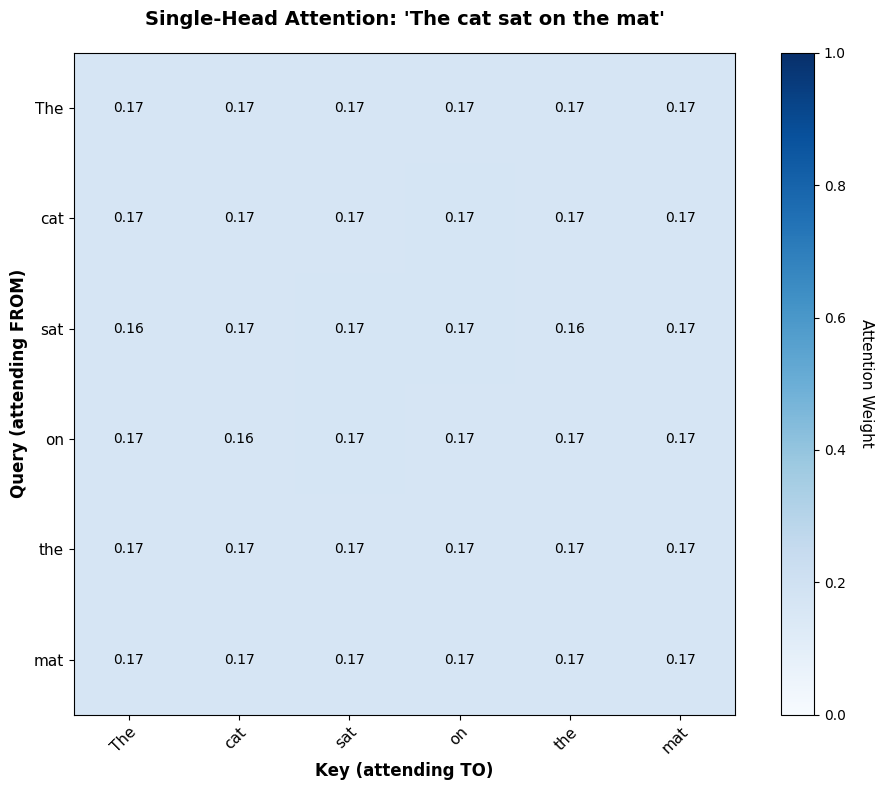

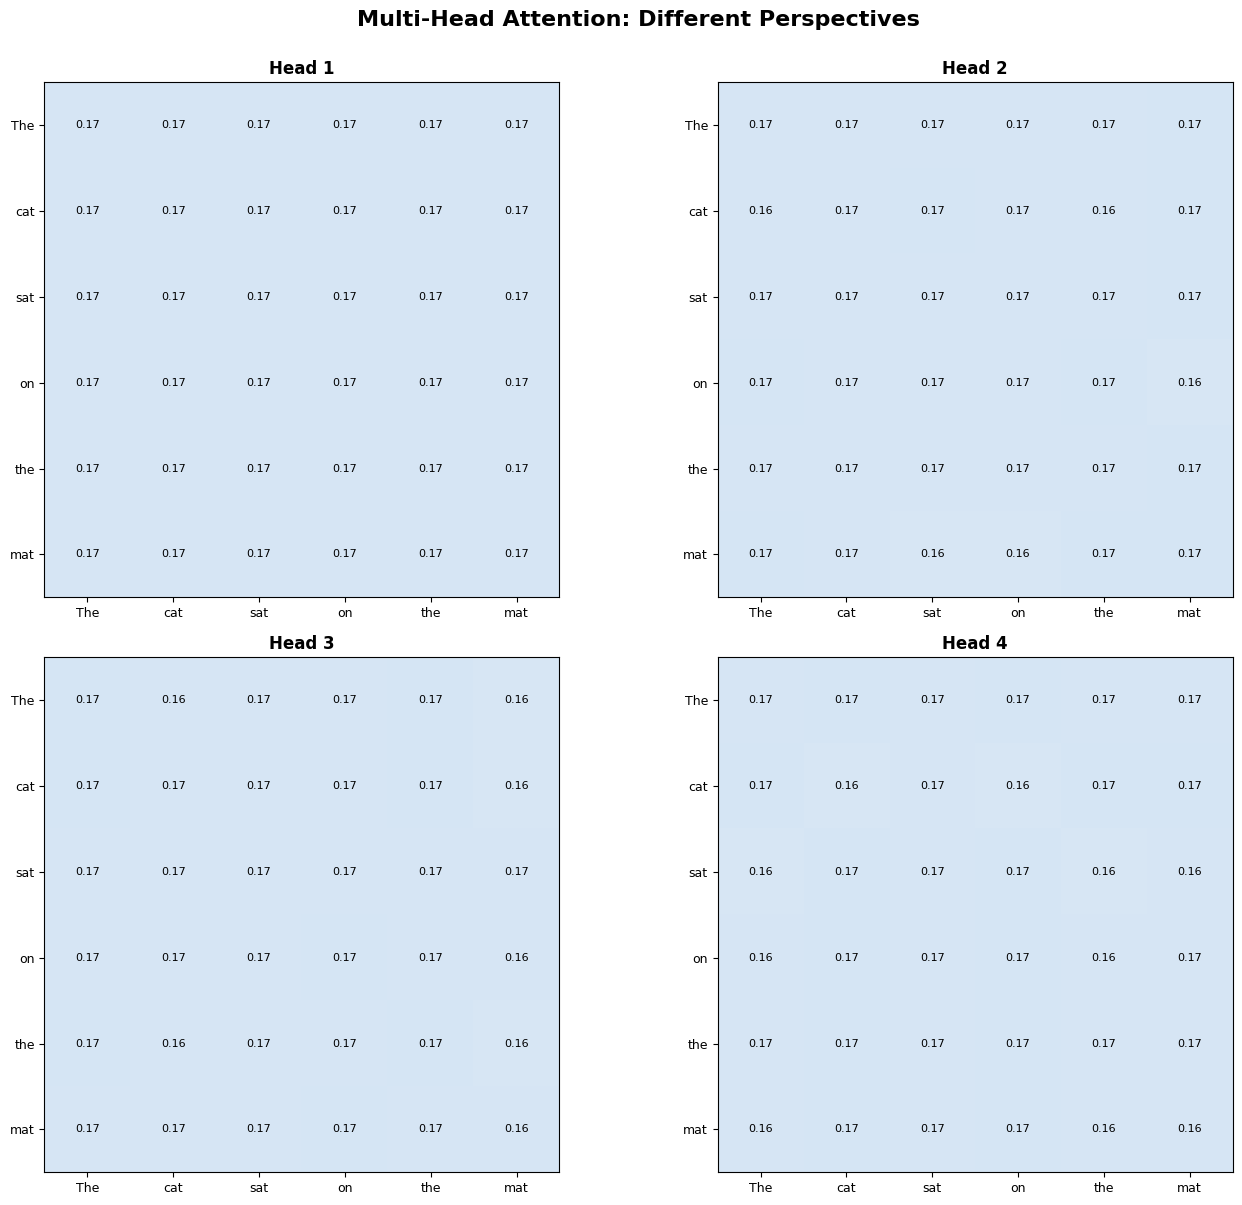

In [4]:
# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def create_embeddings(tokens, d_model=8):
    """
    Create simple embeddings for demonstration.
    
    Args:
        tokens: List of token strings
        d_model: Embedding dimension
        
    Returns:
        Embeddings matrix [len(tokens), d_model]
    """
    # Hand-crafted embeddings with semantic meaning
    embedding_dict = {
        "the": np.array([0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]),
        "cat": np.array([1.0, 0.0, 0.0, 0.0, 0.0, 0.8, 0.0, 0.0]),
        "dog": np.array([1.0, 0.0, 0.0, 0.0, 0.0, 0.8, 0.0, 0.0]),
        "sat": np.array([0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.5, 0.0]),
        "jumped": np.array([0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.9]),
        "on": np.array([0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0]),
        "mat": np.array([0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]),
        "over": np.array([0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0]),
    }
    
    embeddings = []
    for token in tokens:
        if token.lower() in embedding_dict:
            embeddings.append(embedding_dict[token.lower()])
        else:
            embeddings.append(np.random.randn(d_model) * 0.1)
    
    return np.array(embeddings)


def create_causal_mask(seq_len):
    """
    Create causal mask for autoregressive generation.
    
    Returns:
        Mask [seq_len, seq_len] where upper triangle is -inf
    """
    mask = np.triu(np.ones((seq_len, seq_len)) * -1e9, k=1)
    return mask


def visualize_attention(attention_weights, tokens, title="Attention Weights", 
                       save_path=None, figsize=(10, 8)):
    """
    Create heatmap visualization of attention weights.
    
    Args:
        attention_weights: [seq_len, seq_len] attention matrix
        tokens: List of token strings
        title: Plot title
        save_path: Path to save figure (optional)
        figsize: Figure size
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create heatmap
    im = ax.imshow(attention_weights, cmap='Blues', vmin=0, vmax=1)
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(tokens)))
    ax.set_yticks(np.arange(len(tokens)))
    ax.set_xticklabels(tokens, fontsize=11)
    ax.set_yticklabels(tokens, fontsize=11)
    
    # Rotate x labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Add values in cells
    for i in range(len(tokens)):
        for j in range(len(tokens)):
            color = "white" if attention_weights[i, j] > 0.5 else "black"
            ax.text(j, i, f'{attention_weights[i, j]:.2f}',
                   ha="center", va="center", color=color, fontsize=10)
    
    # Labels and title
    ax.set_xlabel("Key (attending TO)", fontsize=12, fontweight='bold')
    ax.set_ylabel("Query (attending FROM)", fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Attention Weight', rotation=270, labelpad=20, fontsize=11)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved to {save_path}")
    
    return fig


def visualize_multihead(head_attentions, tokens, title="Multi-Head Attention", 
                       save_path=None):
    """
    Visualize multiple attention heads.
    
    Args:
        head_attentions: List of [seq_len, seq_len] attention matrices
        tokens: List of token strings
        title: Overall title
        save_path: Path to save figure
    """
    num_heads = len(head_attentions)
    rows = (num_heads + 1) // 2
    cols = 2
    
    fig, axes = plt.subplots(rows, cols, figsize=(14, 6 * rows))
    axes = axes.flatten()
    
    for i, (ax, attn) in enumerate(zip(axes[:num_heads], head_attentions)):
        im = ax.imshow(attn, cmap='Blues', vmin=0, vmax=1)
        ax.set_xticks(np.arange(len(tokens)))
        ax.set_yticks(np.arange(len(tokens)))
        ax.set_xticklabels(tokens, fontsize=9)
        ax.set_yticklabels(tokens, fontsize=9)
        ax.set_title(f'Head {i+1}', fontsize=12, fontweight='bold')
        
        # Add values
        for row in range(len(tokens)):
            for col in range(len(tokens)):
                color = "white" if attn[row, col] > 0.5 else "black"
                ax.text(col, row, f'{attn[row, col]:.2f}',
                       ha="center", va="center", color=color, fontsize=8)
    
    # Hide extra subplots
    for i in range(num_heads, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved to {save_path}")
    
    return fig


# ============================================================================
# DEMONSTRATIONS
# ============================================================================

def demo_single_head():
    """Demonstrate single-head attention."""
    print("="*70)
    print("DEMO 1: Single-Head Attention")
    print("="*70)
    
    # Create sentence
    tokens = ["The", "cat", "sat", "on", "the", "mat"]
    X = create_embeddings(tokens)
    
    print(f"\nSentence: {' '.join(tokens)}")
    print(f"Input shape: {X.shape}")
    
    # Create attention
    attention = SingleHeadAttention(d_model=8, d_k=4)
    output, attn_weights = attention.forward(X, return_attention=True)
    
    print(f"Output shape: {output.shape}")
    
    # Show attention patterns
    print(f"\nAttention patterns:")
    for i, token in enumerate(tokens):
        max_idx = np.argmax(attn_weights[i])
        max_weight = attn_weights[i, max_idx]
        print(f"  '{token}' attends most to '{tokens[max_idx]}' (weight: {max_weight:.3f})")
    
    # Visualize
    visualize_attention(attn_weights, tokens, 
                       title="Single-Head Attention: 'The cat sat on the mat'",
                       save_path="single_head_attention.png")
    
    print("\n" + "="*70 + "\n")


def demo_multi_head():
    """Demonstrate multi-head attention."""
    print("="*70)
    print("DEMO 2: Multi-Head Attention")
    print("="*70)
    
    tokens = ["The", "cat", "sat", "on", "the", "mat"]
    X = create_embeddings(tokens)
    
    print(f"\nSentence: {' '.join(tokens)}")
    
    # Create multi-head attention
    num_heads = 4
    mha = MultiHeadAttention(d_model=8, num_heads=num_heads)
    
    output, head_attentions = mha.forward(X, return_attention=True)
    
    print(f"Number of heads: {num_heads}")
    print(f"Output shape: {output.shape}")
    
    # Show different patterns in each head
    print(f"\nDifferent attention patterns per head:")
    for i, attn in enumerate(head_attentions):
        print(f"\n  Head {i+1}:")
        for j, token in enumerate(tokens):
            max_idx = np.argmax(attn[j])
            print(f"    '{token}' → '{tokens[max_idx]}'")
    
    # Visualize
    visualize_multihead(head_attentions, tokens,
                       title="Multi-Head Attention: Different Perspectives",
                       save_path="multihead_attention.png")
    
    print("\n" + "="*70 + "\n")


def demo_causal_masking():
    """Demonstrate causal masking (GPT-style)."""
    print("="*70)
    print("DEMO 3: Causal Masking (Autoregressive)")
    print("="*70)
    
    tokens = ["The", "cat", "sat", "down"]
    X = create_embeddings(tokens)
    
    print(f"\nSentence: {' '.join(tokens)}")
    
    # Without mask (bidirectional)
    attention_bidir = SingleHeadAttention(d_model=8, d_k=4)
    _, attn_bidir = attention_bidir.forward(X, return_attention=True)
    
    # With causal mask (autoregressive)
    mask = create_causal_mask(len(tokens))
    attention_causal = SingleHeadAttention(d_model=8, d_k=4)
    _, attn_causal = attention_causal.forward(X, mask=mask, return_attention=True)
    
    print("\nCausal mask (upper triangle = cannot attend):")
    print(mask)
    
    # Visualize comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bidirectional
    im1 = ax1.imshow(attn_bidir, cmap='Blues', vmin=0, vmax=1)
    ax1.set_title('Bidirectional (BERT-style)', fontsize=14, fontweight='bold')
    ax1.set_xticks(np.arange(len(tokens)))
    ax1.set_yticks(np.arange(len(tokens)))
    ax1.set_xticklabels(tokens)
    ax1.set_yticklabels(tokens)
    ax1.set_xlabel("Key", fontsize=11)
    ax1.set_ylabel("Query", fontsize=11)
    
    # Causal
    im2 = ax2.imshow(attn_causal, cmap='Blues', vmin=0, vmax=1)
    ax2.set_title('Causal/Autoregressive (GPT-style)', fontsize=14, fontweight='bold')
    ax2.set_xticks(np.arange(len(tokens)))
    ax2.set_yticks(np.arange(len(tokens)))
    ax2.set_xticklabels(tokens)
    ax2.set_yticklabels(tokens)
    ax2.set_xlabel("Key", fontsize=11)
    ax2.set_ylabel("Query", fontsize=11)
    
    # Add values
    for ax, attn in [(ax1, attn_bidir), (ax2, attn_causal)]:
        for i in range(len(tokens)):
            for j in range(len(tokens)):
                color = "white" if attn[i, j] > 0.5 else "black"
                ax.text(j, i, f'{attn[i, j]:.2f}',
                       ha="center", va="center", color=color, fontsize=10)
    
    plt.tight_layout()
    plt.savefig('causal_vs_bidirectional.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved to causal_vs_bidirectional.png")
    plt.close()
    
    print("\nKey difference:")
    print("  - Bidirectional: Can see all tokens (used in BERT)")
    print("  - Causal: Only sees current and previous (used in GPT)")
    
    print("\n" + "="*70 + "\n")


def demo_transformer_layer():
    """Demonstrate complete transformer layer."""
    print("="*70)
    print("DEMO 4: Complete Transformer Layer")
    print("="*70)
    
    tokens = ["The", "cat", "sat", "on", "the", "mat"]
    X = create_embeddings(tokens)
    
    print(f"\nSentence: {' '.join(tokens)}")
    print(f"Input shape: {X.shape}")
    
    # Create transformer layer
    layer = TransformerLayer(d_model=8, num_heads=2, d_ff=32)
    
    print(f"\nTransformer layer configuration:")
    print(f"  Model dimension: 8")
    print(f"  Number of heads: 2")
    print(f"  Feed-forward dimension: 32")
    
    # Forward pass
    output = layer.forward(X)
    
    print(f"\nOutput shape: {output.shape}")
    
    print(f"\nProcessing steps:")
    print(f"  1. Multi-head attention (parallel processing)")
    print(f"  2. Add & Normalize (residual connection)")
    print(f"  3. Feed-forward network (2 layers with ReLU)")
    print(f"  4. Add & Normalize (residual connection)")
    
    print(f"\nThis is ONE layer.")
    print(f"  GPT-2: 12-48 layers")
    print(f"  GPT-3: 96 layers")
    print(f"  GPT-4: Unknown, but likely 100+ layers")
    
    print("\n" + "="*70 + "\n")


def main():
    """Run all demonstrations."""
    print("\n" + "="*70)
    print("ATTENTION MECHANISM: COMPLETE IMPLEMENTATION")
    print("="*70 + "\n")
    
    # Run demos
    demo_single_head()
    demo_multi_head()
    demo_causal_masking()
    demo_transformer_layer()
    
    # Summary
    print("="*70)
    print("SUMMARY")
    print("="*70)
    print("\nYou've implemented:")
    print("  ✓ Single-head attention")
    print("  ✓ Multi-head attention")
    print("  ✓ Causal masking (for GPT-style generation)")
    print("  ✓ Complete transformer layer")
    
    print("\nKey insights:")
    print("  • Attention = weighted retrieval based on similarity")
    print("  • Multi-head = multiple perspectives simultaneously")
    print("  • Masking = control what information flows where")
    print("  • Transformers = stack many layers for deep understanding")
    
    print("\nVisualizations saved:")
    print("  • single_head_attention.png")
    print("  • multihead_attention.png")
    print("  • causal_vs_bidirectional.png")
    
    print("\nNext steps:")
    print("  1. Experiment with different sentences")
    print("  2. Try different numbers of heads")
    print("  3. Move to Project 4: LoRA (efficient fine-tuning)")
    
    print("="*70 + "\n")


if __name__ == "__main__":
    main()